# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("RL_results.tsv", sep="\t")
df["total_reward"] = pd.to_numeric(df["Post_RL_total_reward"], errors="coerce")
df["status"] = df["status(keep/discard)"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 51
Columns: ['commit', 'Post_RL_total_reward', 'numerical_reward', 'format_reward', 'status(keep/discard)', 'description', 'total_reward', 'status']


,commit,Post_RL_total_reward,numerical_reward,format_reward,status(keep/discard),description,total_reward,status
0,b2ee2a0,146.484375,53.125000,93.359375,keep,baseline,146.484375,KEEP
1,5dc3849,131.250000,45.312500,85.937500,discard,Exp 1: lower LR to 5e-6,131.250000,DISCARD
2,84deabe,135.937500,41.796875,94.140625,discard,Exp 2: higher LR to 2e-5,135.937500,DISCARD
3,daabfdd,134.375000,46.484375,87.890625,discard,Exp 3: LoRA RANK 128,134.375000,DISCARD
4,9cc4d3e,137.109375,39.843750,97.265625,discard,Exp 4: LoRA ALPHA 128,137.109375,DISCARD
5,2ce665c,133.203125,44.921875,88.281250,discard,Exp 5: LoRA ALPHA 32.0,133.203125,DISCARD
6,a329141,146.484375,53.125000,93.359375,discard,Exp 6: EPSILON 0.1,146.484375,DISCARD
7,feeb3f8,146.484375,53.125000,93.359375,discard,Exp 7: EPSILON 0.3,146.484375,DISCARD
8,4f7955e,143.750000,48.046875,95.703125,discard,Exp 8: BETA 0.04,143.750000,DISCARD
9,494692a,142.187500,50.390625,91.796875,discard,Exp 9: BETA 0.12,142.187500,DISCARD


In [11]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    49
KEEP        2

Keep rate: 2/51 = 3.9%


In [12]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    total_reward = row["total_reward"]
    desc = row["description"]
    print(f"  #{i:3d}  total_reward={total_reward:.6f}  {desc}")

KEPT experiments (2 total):

  #  0  total_reward=146.484375  baseline
  # 43  total_reward=150.000000  Exp 43: SEED 1


## Total Over Time

Track how the best (kept) total reward evolves as experiments progress. The running maximum shows the "frontier" -- the best result achieved so far.

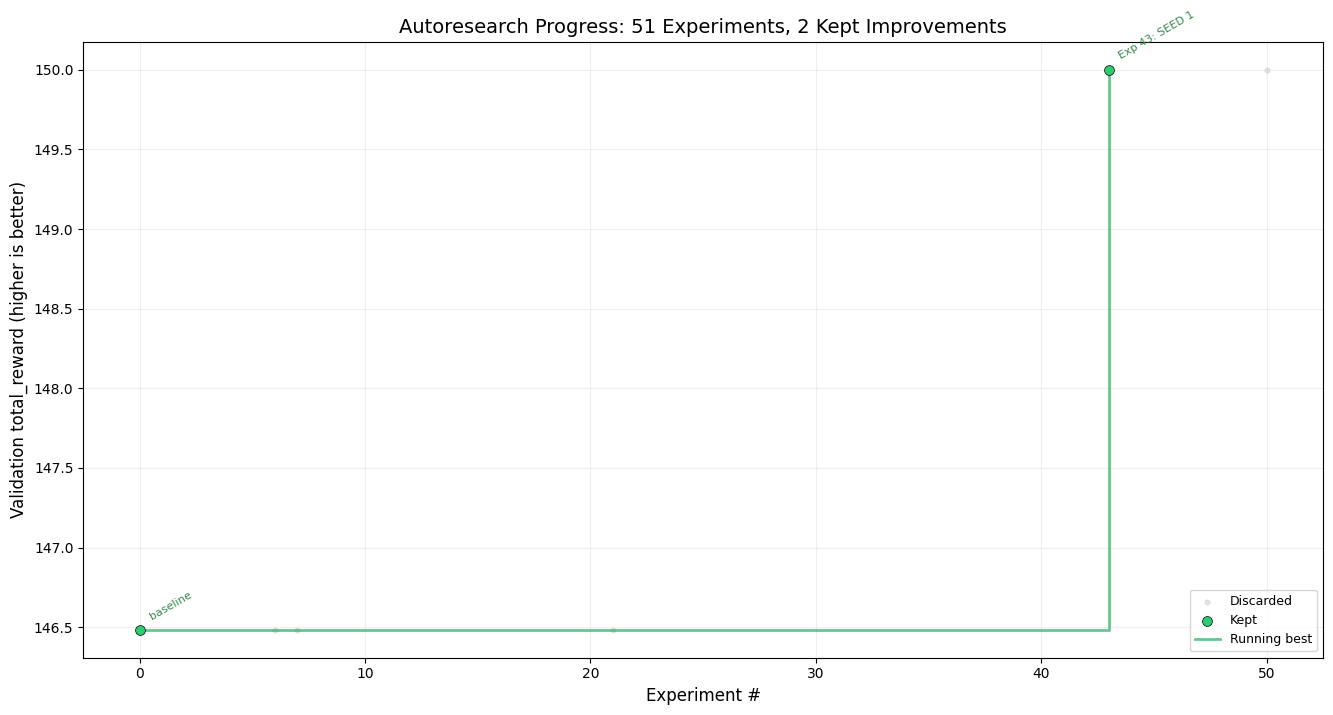

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_total_reward = valid.loc[0, "total_reward"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["total_reward"] >= baseline_total_reward - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["total_reward"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["total_reward"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_total_reward = valid.loc[kept_mask, "total_reward"]
running_max = kept_total_reward.cummax() # Changed to cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, total_reward in zip(kept_idx, kept_total_reward):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, total_reward),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")
    
# Fixed fallback variable from baseline_bpb to baseline_total_reward
best = running_max.iloc[-1] if len(running_max) > 0 else baseline_total_reward
n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation total_reward (higher is better)", fontsize=12) # Updated label
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9) # Moved to lower right so the rising line doesn't collide with it
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
margin = (best - baseline_total_reward) * 0.15
# Added absolute value fallback just in case best == baseline